# KDA（Kimi Delta Attention）：门控遗忘 ⊕ delta 纠错

线性注意力把整段历史压进一个固定大小的**状态矩阵** $S\in\mathbb R^{K\times V}$，每来一个 token 更新一次、
读出 $o_t=S_t^\top q_t$。前两章给了两种互补的"状态管理"思路：

- **第 10 章 GLA**：$S_t=\operatorname{diag}(e^{g_t})\,S_{t-1}+k_tv_t^\top$ —— per-channel 门控**遗忘**，但写入"只加不改"；
- **第 11 章 DeltaNet**：$S_t=(I-\beta_t k_tk_t^\top)\,S_{t-1}+\beta_t k_tv_t^\top$ —— delta rule **定向纠错**，但不会遗忘。

**KDA 把两者合二为一**（Moonshot *Kimi Linear* 的核心线性注意力主干）：既能按通道选择性遗忘、又能在 key
方向纠错覆盖。这一章我们把它的数学一步步推到底：

1. §2 简回顾 **delta rule 的几何**（详解在第 11 章）；
2. §3 讲清 **KDA = 门控 ⊕ 纠错** 的 gated delta rule，并可视化门控如何控制"记忆窗口"；
3. §4 推导 **WY 表示**——把块内串行擦除解成一次三角求逆，这是 chunk 并行 kernel 的地基；
4. §5 **逐段精读**可读的 chunk 参考实现（每段标注对应公式与真实 Triton kernel）；
5. §6 保留**完整 kernel 源码**并验证本仓库解耦自 fla 的实现与原版数值一致。

In [1]:
import sys, math
from pathlib import Path

import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CH = ROOT / "12-kda"
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(CH))
sys.path.insert(0, str(ROOT / "10-linear-attention")); sys.path.insert(0, str(ROOT / "11-deltanet"))

from common.nbtools import setup_cjk, show_code
setup_cjk()                                       # 中文字体 + retina 高清出图
from kda import kda_recurrent                      # KDA 简要版（gated delta rule）
from kda_naive import naive_recurrent_kda, naive_chunk_kda   # fla 参考（ground truth）
from deltanet import delta_rule_recurrent          # 退化对比

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0))

跑在 NVIDIA GeForce RTX 4090


## 1. 一条线看懂三代：状态更新规则

线性注意力的全部差异，只在"状态 $S$ 每步怎么更新"这一行：

$$
\begin{aligned}
\textbf{GLA}\;&: & S_t&=\operatorname{diag}(e^{g_t})\,S_{t-1}+k_tv_t^\top &&\text{(per-ch 遗忘，写入只加)}\\
\textbf{DeltaNet}\;&: & S_t&=(I-\beta_t\,k_tk_t^\top)\,S_{t-1}+\beta_t\,k_tv_t^\top &&\text{(delta 纠错，无遗忘)}\\
\textbf{KDA}\;&: & S_t&=(I-\beta_t\,k_tk_t^\top)\,\operatorname{diag}(e^{g_t})\,S_{t-1}+\beta_t\,k_tv_t^\top &&\text{(遗忘+纠错)}
\end{aligned}
$$

KDA 同时含两个旋钮：门控 $g_t\in\mathbb R^K$（来自 GLA）+ delta 纠错 $\beta_t$（来自 DeltaNet）。当 $g_t\equiv0$
（即 $e^{g_t}=1$，不遗忘）时，KDA 应**精确退化为 DeltaNet**。先把这条退化钉死。

In [2]:
B, H, T, D = 2, 2, 128, 64
q = torch.randn(B, H, T, D, device="cuda")
k = torch.randn(B, H, T, D, device="cuda")
v = torch.randn(B, H, T, D, device="cuda")
beta = torch.rand(B, H, T, device="cuda")

g0 = torch.zeros(B, H, T, D, device="cuda")                  # g=0 → 不遗忘
o_kda_g0 = kda_recurrent(q, k, v, g0, beta, l2norm=True)
o_delta = delta_rule_recurrent(q, k, v, beta, l2norm=True)
print(f"KDA(g=0) vs DeltaNet  max diff: {(o_kda_g0 - o_delta).abs().max().item():.2e}")
print("→ g=0 时 KDA 精确退化为 DeltaNet（门控关掉，只剩 delta 纠错）。KDA 就是给 DeltaNet 加上 GLA 的门控。")

KDA(g=0) vs DeltaNet  max diff: 0.00e+00
→ g=0 时 KDA 精确退化为 DeltaNet（门控关掉，只剩 delta 纠错）。KDA 就是给 DeltaNet 加上 GLA 的门控。


## 2. 简回顾：delta rule 的几何（详见第 11 章）

朴素线性注意力 $S_t=S_{t-1}+k_tv_t^\top$ 的毛病是"只加不改"：$k_i$ 之间不正交时读 $k_t$ 会混进别的 $v_i$（键冲突），
旧错误也无法覆盖。**delta rule** 把"写入"改成"先擦后写"——先用 $k_t$ 读出旧值 $\hat v_t=S_{t-1}^\top k_t$，再写入
修正量 $\beta_t k_t(v_t-\hat v_t)^\top$。把 $\hat v_t$ 代回去合并，得到

$$S_t=S_{t-1}+\beta_t k_t(v_t-S_{t-1}^\top k_t)^\top=\underbrace{(I-\beta_t k_tk_t^\top)}_{\text{沿 }k_t\text{ 擦除}}S_{t-1}+\beta_t k_tv_t^\top.$$

当 $\lVert k_t\rVert=1,\beta_t=1$ 时 $(I-k_tk_t^\top)$ 是把状态在 $k_t$ 方向分量清零的正交投影——**写入前先沿 $k_t$ 擦掉
旧值**。这根治了键冲突。（几何 2D 图与完整推导见第 11 章 §2。）

## 3. KDA = GLA 门控 ⊕ DeltaNet 纠错

KDA 在 delta rule 的擦除算子之外，再给状态乘一个 **per-channel 衰减门** $\operatorname{diag}(e^{g_t})$（$g_t\le0$，
故 $e^{g_t}\in(0,1]$），让久未覆盖的内容主动遗忘。逐 token 展开成"先门控、再纠错、后读出"四步（即 `kda.py` 循环体）：

$$
\underbrace{\hat S=\operatorname{diag}(e^{g_t})S_{t-1}}_{\text{① GLA 门控：per-channel 遗忘}},\quad
\underbrace{\hat v_t=\hat S^\top k_t}_{\text{② 查询门控后的旧值}},\quad
\underbrace{S_t=\hat S+\beta_t\,k_t(v_t-\hat v_t)^\top}_{\text{③ DeltaNet delta 纠错}},\quad
\underbrace{o_t=S_t^\top q_t}_{\text{④ 读出}}.
$$

- $e^{g_t}$（$g_t$ 是 log-space、**per-channel** 的衰减）让状态按通道选择性遗忘（来自 GLA）；
- $\beta_t k_t(v_t-\hat v_t)^\top$ 用 $k_t$ 查询门控后的旧状态、算误差、定向擦写（来自 DeltaNet delta rule）。

于是 KDA 既能"按通道遗忘旧信息"，又能"在 key 方向纠错覆盖"——比单独的 GLA（不纠错）或 DeltaNet（不遗忘）记忆
管理都更强。这正是 Kimi Linear 用它做长上下文骨干的原因。下面把门控 $g$ 对"记忆窗口"的控制画出来。

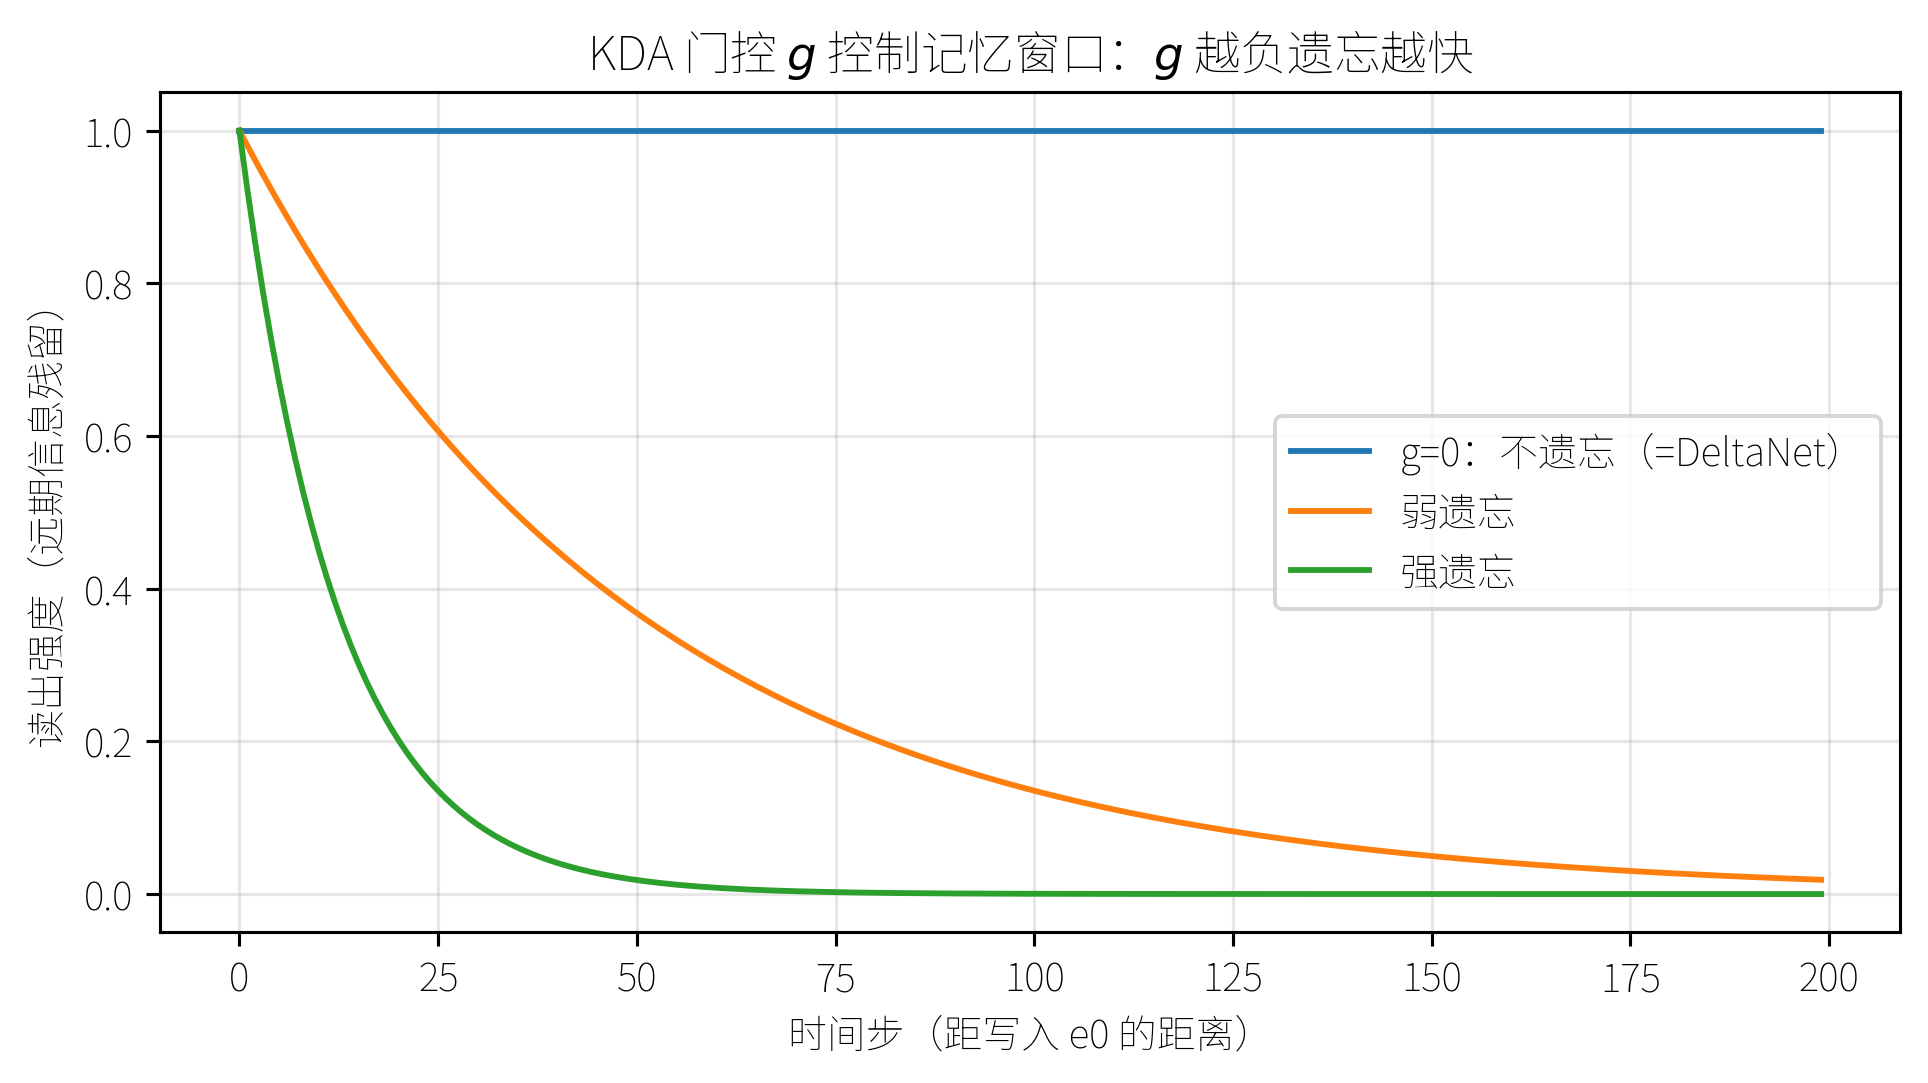

g=0 信息不衰减（DeltaNet 行为）；g<0 按通道指数遗忘（GLA 行为）。KDA 二者兼得。


In [3]:
# 在 t=0 写入一条信息 (e0->e0)，之后每步用 e0 查询，看读出强度随 g 的衰减
T = 200
def memory_trace(g_val):
    q = torch.zeros(1, 1, T, 16, device="cuda"); k = torch.zeros(1, 1, T, 16, device="cuda")
    v = torch.zeros(1, 1, T, 16, device="cuda"); beta = torch.ones(1, 1, T, device="cuda")
    k[0, 0, 0, 0] = 1.0; v[0, 0, 0, 0] = 1.0          # t=0 写 (e0 -> e0)
    q[:, :, :, 0] = 1.0                                # 每步都用 e0 query
    g = torch.full((1, 1, T, 16), g_val, device="cuda")
    return kda_recurrent(q, k, v, g, beta, l2norm=False, scale=1.0)[0, 0, :, 0].detach().cpu().numpy()

plt.figure(figsize=(7, 4))
for gv, name in [(0.0, "g=0：不遗忘（=DeltaNet）"), (-0.02, "弱遗忘"), (-0.08, "强遗忘")]:
    plt.plot(memory_trace(gv), label=name)
plt.xlabel("时间步（距写入 e0 的距离）"); plt.ylabel("读出强度（远期信息残留）")
plt.legend(); plt.title("KDA 门控 $g$ 控制记忆窗口：$g$ 越负遗忘越快"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("g=0 信息不衰减（DeltaNet 行为）；g<0 按通道指数遗忘（GLA 行为）。KDA 二者兼得。")

## 4. chunk 并行的数学核心：WY 表示（逐步推导）

recurrent 形式 $O(T)$ 串行、GPU 上慢。生产 kernel 用 **chunk-parallel**：序列切成大小 $C$（fla 里 $C=64$）的块，
**块内**矩阵化一次算完、**块间**用状态递推。难点在块内——擦除算子逐 token 串行相乘。把它化成一次三角求逆：

### 4.1 块内展开：串行的下三角依赖

只看一个块（块起点状态记为 $S$）。把 $g$ 的块内前缀和记为 $g^{\mathrm{cum}}$ 折进衰减。块内第 $i$ 步的**有效写入**
$u_i$ 要先擦掉 $k_i$ 方向的旧值，而这"旧值"里就含同块内前面 $j<i$ 步刚写进去的 $u_j$：

$$u_i=v_i-\sum_{j<i}\underbrace{\beta_i\,\bigl(k_i^\top k_j\bigr)\,e^{\,g^{\mathrm{cum}}_i-g^{\mathrm{cum}}_j}}_{=\,T_{ij}}\,u_j.$$

于是 $u_i$ 依赖所有 $u_j\ (j<i)$——一个**严格下三角**的串行依赖。

### 4.2 写成线性方程组，一次解开

把块内 $u_i$ 摞成 $U$、$v_i$ 摞成 $V$，上式即

$$U=V-T\,U\;\Longrightarrow\;(I+T)\,U=V\;\Longrightarrow\;\boxed{U=(I+T)^{-1}V}.$$

这就是 **WY / UT transform**：严格下三角矩阵 $T$ 编码块内所有"擦除-写入"相互作用，求一次逆就把 $C$ 步串行依赖
一次性解开。其中

$$T_{ij}=\beta_i\sum_d k_{i,d}\,k_{j,d}\,e^{\,g^{\mathrm{cum}}_{i,d}-g^{\mathrm{cum}}_{j,d}}\quad(i>j),$$

即"位置 $i$ 的 key 撞上位置 $j$ 的 key"的强度，乘纠错系数 $\beta_i$、带 $i,j$ 间逐通道衰减。（KDA 是单 $\beta$，对比第
13 章 GDN-2 的 erase/write 双门，这里 erase-read 与 write 用同一个 $k$、同一个 $\beta$。）

### 4.3 前向替换 + 块间递推

$T$ 严格下三角 $\Rightarrow I+T$ 单位下三角，用**前向替换**逐行 $O(C^2)$ 求逆（`naive_chunk_kda` 的 `for i` 循环）。
解出 $U,W=(I+T)^{-1}(e^{g^{\mathrm{cum}}}\!\odot k)$ 后，块间带入状态 $S$：

$$v^{\text{new}}=U-W\,S,\quad o=(q\odot e^{g^{\mathrm{cum}}})\,S+\underbrace{(\text{块内因果 }QK^\top\text{含衰减})}_{A_{qk}}v^{\text{new}},\quad S\leftarrow\operatorname{diag}(e^{g^{\mathrm{cum}}_{\text{last}}})S+\tilde k^\top v^{\text{new}}.$$

下面验证：(a) 前向替换确实给出 $(I+T)^{-1}$；(b) 整套 chunk 算法与 $O(T)$ recurrent 数值一致。

In [4]:
# (a) 前向替换求逆：A @ (I+T) == I（单位下三角）
C = 16
torch.manual_seed(3)
Tm = torch.randn(C, C, device="cuda").tril(-1)
A = -Tm.clone()
for i in range(1, C):
    A[i, :i] = A[i, :i] + (A[i, :i, None] * A[:i, :i]).sum(0)
A = A + torch.eye(C, device="cuda")
err = (A @ (torch.eye(C, device="cuda") + Tm) - torch.eye(C, device="cuda")).abs().max()
print(f"(a) 前向替换 A=(I+T)^(-1)：‖A(I+T)-I‖∞ = {err.item():.2e}")

# (b) chunk(WY) == recurrent（预先 L2norm，否则未归一化 k 让 delta rule 谱半径爆炸 → nan）
B, T, H, D = 2, 256, 3, 64
gg = torch.Generator("cuda").manual_seed(2)
q = F.normalize(torch.randn(B, T, H, D, device="cuda", generator=gg), dim=-1)
k = F.normalize(torch.randn(B, T, H, D, device="cuda", generator=gg), dim=-1)
v = torch.randn(B, T, H, D, device="cuda", generator=gg)
g = F.logsigmoid(torch.randn(B, T, H, D, device="cuda", generator=gg))
beta = torch.rand(B, T, H, device="cuda", generator=gg)
o_chunk, _ = naive_chunk_kda(q, k, v, g, beta, chunk_size=64)
o_rec, _ = naive_recurrent_kda(q, k, v, g, beta)
print(f"(b) chunk(WY) vs recurrent：max diff = {(o_chunk - o_rec).abs().max().item():.2e}")
print("→ WY 把块内串行擦除解成一次三角求逆，与 O(T) recurrent 逐位等价——chunk kernel 的数学地基成立。")

(a) 前向替换 A=(I+T)^(-1)：‖A(I+T)-I‖∞ = 1.46e-05
(b) chunk(WY) vs recurrent：max diff = 8.94e-08
→ WY 把块内串行擦除解成一次三角求逆，与 O(T) recurrent 逐位等价——chunk kernel 的数学地基成立。


## 5. 逐段精读：真正的 chunk 实现

§4 的数学，对应代码就是 fla 的参考实现 `naive_chunk_kda`（本仓库已拷为 `kda_naive.py`）——可读的 PyTorch chunk 算法，
和公式一一对应。生产 Triton kernel 做同一件事，只是为并行切了块。下面拆成 3 段精读，每段标注公式与 Triton 位置。

### 5.1 门控前缀和 + 构造严格下三角 $T$、前向替换求逆

```python
# kda_naive.py · naive_chunk_kda（节选）
g = g.cumsum(-2)                                   # 块内 g 前缀和 g^cum（§4.1 的衰减折算）
A = torch.zeros(*g.shape[:-1], BT)
for i in range(BT):                                # A_ic = Σ_d k_cd k_id e^{g^cum_c - g^cum_i}
    A[..., i] = torch.einsum('...cd,...d->...c', k * (g - g[..., i:i+1, :]).exp(), k[..., i, :])
A = -(A * beta[..., None]).masked_fill(mask, 0)    # 乘 β、取严格下三角 → -T
for i in range(1, BT):                             # 前向替换：单位下三角逐行求逆（§4.3）
    A[..., i, :i] += (A[..., i, :, None] * A[..., :, :i]).sum(-2)
A = (A + torch.eye(BT)) * beta[..., None, :]       # A = (I+T)^{-1}，并入 β
```

这段就是 §4.2 的 $T_{ij}=\beta_i\sum_d k_{i,d}k_{j,d}\,e^{g^{\mathrm{cum}}_i-g^{\mathrm{cum}}_j}$ 与前向替换求 $(I+T)^{-1}$。

> **真实 Triton 对应**：门控前缀和在 `_fla_kda_cumsum.py::chunk_local_cumsum`；构造 $T$（kernel 里叫 `Akk`）与分块
> 前向替换求逆在 `_fla_kda_chunk_intra.py`（KDA 最大的 kernel，943 行）。

### 5.2 WY 辅助量 + 块间循环

```python
w = A @ (g.exp() * k)                              # W = (I+T)^{-1}(e^{g^cum} ⊙ k)
u = A @ v                                          # U = (I+T)^{-1} v
S = torch.zeros(B, HV, K, V)                       # 跨块状态
for i in range(NT):
    Aqk = ... q_i*(g_i-g_j).exp() · k_j ...        # 块内因果 QK^T（含衰减）
    v_i = u[:, :, i] - w[:, :, i] @ S              # v^new = U - W·S（§4.3）
    o[:, :, i] = (q_i * g_i.exp()) @ S + Aqk @ v_i # 块间贡献 + 块内贡献
    S = S * g_i[:, :, -1].exp()[..., None]         # 状态衰减
    S += ((g_i[:, :, -1:] - g_i).exp() * k_i).transpose(-1, -2) @ v_i   # + 本块写入
```

§4.3 的三个公式：用块起点 $S$ 修正出 $v^{\text{new}}$，输出 = 块内因果注意力 + 块间状态读出，最后把状态传给下个块。
$NT$ 个块之间只有这一条 $S$ 的串行链（$O(T/C)$ 步），块内全部并行——这就是 chunk-parallel 把 $O(T)$ 降到 $O(T/C)$ 串行的原理。

> **真实 Triton 对应**：块间状态递推在 `_fla_kda_chunk_delta_h.py`；输出在 `_fla_kda_gla_chunk.py`（KDA 复用 GLA 的输出 kernel）。

## 6. 真实 Triton kernel：完整解耦自 fla

本仓库**完整拷贝并解耦** KDA 的 14 个 Triton 文件（计算逻辑一字未改），靠三招脱离 fla 独立运行：**no-op dispatch**
（绕后端分派）+ **cp stub**（绕多卡 context-parallel）+ **复用 gla.chunk**（KDA 借 GLA 的输出函数）。下面保留**完整源码**
——KDA 最核心的 WY 求逆 kernel `_fla_kda_chunk_intra.py`（943 行，可滚动）。前面 §5.1 精读的 $T$ 构造与前向替换都在里头；
其余 13 个文件见 [`SOURCES.md`](./SOURCES.md)。

In [5]:
show_code(str(CH / "_fla_kda_chunk_intra.py"))

### 数值验证：解耦没改任何计算

把本地解耦的 kernel 与 fla 原版逐位对比（定长 + 变长 `cu_seqlens`），再与简要版 recurrent 对齐：

In [6]:
from _fla_kda_chunk import chunk_kda as local
B, T, H, D = 2, 512, 4, 64
gg = torch.Generator("cuda").manual_seed(1)
q = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
k = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
v = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
g = F.logsigmoid(torch.randn(B, T, H, D, device="cuda", dtype=torch.float32, generator=gg))
beta = torch.rand(B, T, H, device="cuda", dtype=torch.bfloat16, generator=gg)

ol, _ = local(q, k, v, g, beta, use_qk_l2norm_in_kernel=True)
try:
    from fla.ops.kda import chunk_kda as flak
    of, _ = flak(q, k, v, g, beta, use_qk_l2norm_in_kernel=True)
    print(f"① 定长：本地解耦 vs fla 原版   max diff: {(ol.float()-of.float()).abs().max().item():.2e}")
    cu = torch.tensor([0, 200, 512, 800, 1024], device="cuda", dtype=torch.int32)
    qp, kp, vp, gp = (x.reshape(1, B * T, H, D) for x in (q, k, v, g)); bp = beta.reshape(1, B * T, H)
    o2, _ = local(qp, kp, vp, gp, bp, use_qk_l2norm_in_kernel=True, cu_seqlens=cu)
    f2, _ = flak(qp, kp, vp, gp, bp, use_qk_l2norm_in_kernel=True, cu_seqlens=cu)
    print(f"② 变长(cu_seqlens)：本地 vs fla    max diff: {(o2.float()-f2.float()).abs().max().item():.2e}")
except ImportError:
    print("（未装 fla，跳过原版对照）")

o_rec = kda_recurrent(*(x.transpose(1, 2) for x in (q, k, v, g)), beta.transpose(1, 2), l2norm=True).transpose(1, 2)
print(f"③ 本地 chunk vs 简要版 recurrent   max diff: {(ol.float()-o_rec.float()).abs().max().item():.2e}")
print("→ 完整解耦（14 文件 + cp stub）没改任何计算：与 fla 数值一致、与 recurrent ground truth 对齐。")

① 定长：本地解耦 vs fla 原版   max diff: 2.44e-04


② 变长(cu_seqlens)：本地 vs fla    max diff: 0.00e+00
③ 本地 chunk vs 简要版 recurrent   max diff: 8.87e-04
→ 完整解耦（14 文件 + cp stub）没改任何计算：与 fla 数值一致、与 recurrent ground truth 对齐。


## 7. 反向传播：梯度怎么流过 gated chunk

§1–§6 都在讲 forward；训练靠 backward。KDA 的 `chunk_bwd` 在 DeltaNet（第 11 章 §6）的反向之上，多出一条
**per-channel 门控梯度 $dg$**。难点仍是那两处，再加门控：

1. 状态 $S$ 在块间**串行 carry** → backward 必须**反向扫描**（BPTT，从后往前累积状态梯度 $dS$）；
2. WY 表示里有**矩阵求逆** $T=(I+L)^{-1}$ → 它的反向是**矩阵求逆的梯度**，不是普通矩阵乘；
3. 每块的 per-channel 衰减 $e^{g^{\mathrm{cum}}}$ 折进了 $\hat k,\bar k,\hat q,k_{\text{tail}}$ 与状态衰减，这些指数项的梯度都要**汇回 $dg$**（块内前缀和的反向是后缀和）。

下面把它们推清楚，再手推**完整 backward** 用 autograd **逐位钉死**。

### 7.1 三个关键反向（+ 门控）

记 forward（块 $n$，$S$ 为进入该块的状态，$\gamma=g$ 的块内前缀和、per-channel）。把衰减折进
$\hat k=k\odot e^{\gamma},\ \bar k=k\odot e^{-\gamma},\ \hat q=q\odot e^{\gamma}$，则

$$L_n=\operatorname{strict\_tril}\!\big(\operatorname{diag}(\beta)\,\hat K\bar K^\top\big),\quad T_n=(I+L_n)^{-1},\quad U=T_n(\beta\odot v),\quad W=T_n(\beta\odot\hat k),\quad A_n=\operatorname{tril}(\hat Q\bar K^\top),$$
$$\tilde u_n=U-WS,\qquad o_n=\hat Q\,S+A_n\tilde u_n,\qquad S'=\operatorname{diag}(e^{\gamma_{\text{last}}})\,S+k_{\text{tail}}^\top\tilde u_n,\quad k_{\text{tail}}=k\odot e^{\gamma_{\text{last}}-\gamma}.$$

**① 块内（标准矩阵乘反向）**：由 $o_n=\hat Q S+A_n\tilde u_n$ 得 $d\hat Q\mathrel{+}=do_n\,S^\top$、$dA_n=do_n\,\tilde u_n^\top$、
$d\tilde u_n\mathrel{+}=A_n^\top do_n$（$A_n$ 梯度 mask 回下三角）。

**② 块间反向扫描（BPTT）**：$S'=\operatorname{diag}(e^{\gamma_{\text{last}}})S+k_{\text{tail}}^\top\tilde u_n$ 把状态梯度 $dS$ 从后往前传——

$$dS\mathrel{+}=\operatorname{diag}(e^{\gamma_{\text{last}}})\,dS',\qquad dk_{\text{tail}}=\tilde u_n\,dS'^\top,\qquad d\tilde u_n\mathrel{+}=k_{\text{tail}}\,dS';$$

再配 $\tilde u_n=U-WS$ 补 $dS\mathrel{-}=W^\top d\tilde u_n$。**从 $n=N{-}1$ 倒扫到 $0$**，$dS$ 一路累积——这正是 RNN 的 BPTT。

**③ WY 求逆梯度**：$U=T_n(\beta\odot v),\ W=T_n(\beta\odot\hat k)$ 给出 $dT_n=dU\,(\beta\odot v)^\top+dW\,(\beta\odot\hat k)^\top$；再用
**矩阵求逆梯度** $\big(Y=X^{-1}\Rightarrow dX=-Y^\top dY\,Y^\top\big)$：

$$dL_n=\operatorname{strict\_tril}\!\big(-T_n^\top\,dT_n\,T_n^\top\big).$$

**④ 门控梯度 $dg$**：$\hat k,\bar k,\hat q,k_{\text{tail}}$ 与状态衰减 $e^{\gamma_{\text{last}}}$ 里每个 $e^{\pm\gamma}$ 都把梯度汇成 $d\gamma$，
最后 $dg=\operatorname{rev\_cumsum}(d\gamma)$（前缀和的反向 = 后缀和）。这是 KDA 相对 DeltaNet 唯一多出来的一条链。

In [7]:
# 手推 KDA chunk backward，用 autograd 逐位钉死（小尺寸显式分块；scale/l2norm 是独立标准 bwd，这里聚焦 gated chunk 代数）
dev = "cuda"
B_, H_, T_, D_, C_ = 1, 1, 12, 4, 4
N_ = T_ // C_
eye = torch.eye(C_, device=dev)
strict = torch.triu(torch.ones(C_, C_, device=dev), 1).bool()      # 严格上三角（A 要置 0）
incl = torch.triu(torch.ones(C_, C_, device=dev), 0).bool()        # 含对角上三角（L 要置 0）

def fwd(q, k, v, g, beta, store):
    qc, kc, vc, gc = (x.view(B_, H_, N_, C_, -1) for x in (q, k, v, g)); bc = beta.view(B_, H_, N_, C_)
    o = torch.zeros(B_, H_, N_, C_, D_, device=dev); S = torch.zeros(B_, H_, D_, D_, device=dev)
    for n in range(N_):
        qn, kn, vn, gn, bn = qc[:, :, n], kc[:, :, n], vc[:, :, n], gc[:, :, n], bc[:, :, n]
        gam = gn.cumsum(-2); E = gam.exp(); Ei = (-gam).exp(); glast = gam[..., -1, :]   # g^cum 块内前缀和（per-channel）
        hk = kn * E; kbar = kn * Ei; hq = qn * E                                          # 把衰减折进 k/q
        P = hk @ kbar.transpose(-1, -2)
        L = (bn[..., :, None] * P).masked_fill(incl, 0.)                                  # L_ij=β_i(k_i·k_j)e^{g_i-g_j} 严格下三角
        Tn = torch.linalg.inv(eye + L)                                                    # WY 求逆 T=(I+L)^{-1}
        vb = bn[..., None] * vn; kb = bn[..., None] * hk
        U = Tn @ vb; W = Tn @ kb                                                          # U=T(βv), W=T(β·k̂)
        A = (hq @ kbar.transpose(-1, -2)).masked_fill(strict, 0.)                         # 块内因果含衰减 QK^T
        uh = U - W @ S
        o[:, :, n] = hq @ S + A @ uh
        Ktail = kn * (glast[..., None, :] - gam).exp()
        store.append(dict(gam=gam, E=E, Ei=Ei, glast=glast, bn=bn, hk=hk, kbar=kbar, hq=hq, P=P,
                          Tn=Tn, vb=vb, kb=kb, W=W, A=A, uh=uh, Sn=S.clone(), Ktail=Ktail, qn=qn, kn=kn, vn=vn))
        S = E[..., -1, :][..., None] * S + Ktail.transpose(-1, -2) @ uh
    return o.view(B_, H_, T_, D_)

def bwd(do, store):
    doc = do.view(B_, H_, N_, C_, D_)
    dq = torch.zeros(B_, H_, N_, C_, D_, device=dev); dk = torch.zeros_like(dq); dv = torch.zeros_like(dq)
    dg = torch.zeros_like(dq); dbeta = torch.zeros(B_, H_, N_, C_, device=dev); dS = torch.zeros(B_, H_, D_, D_, device=dev)
    for n in reversed(range(N_)):
        s = store[n]
        gam, E, Ei, glast, bn, hk, kbar, hq, P, Tn, vb, kb, W, A, uh, Sn, Ktail, qn, kn, vn = (s[x] for x in
            ("gam", "E", "Ei", "glast", "bn", "hk", "kbar", "hq", "P", "Tn", "vb", "kb", "W", "A", "uh", "Sn", "Ktail", "qn", "kn", "vn"))
        do_n = doc[:, :, n]; dgam = torch.zeros_like(gam)
        dhk = torch.zeros_like(kn); dkbar = torch.zeros_like(kn); dhq = torch.zeros_like(qn)
        El = E[..., -1, :]                                                                # ② 块间 BPTT 反向扫描
        dS_state = El[..., None] * dS; dEl = (Sn * dS).sum(-1)
        dKtail = uh @ dS.transpose(-1, -2); duh = Ktail @ dS
        dglast = dEl * El; dk[:, :, n] = dKtail * (glast[..., None, :] - gam).exp()
        tmp = dKtail * Ktail; dglast = dglast + tmp.sum(-2); dgam = dgam - tmp
        dhq = dhq + do_n @ Sn.transpose(-1, -2); dS_state = dS_state + hq.transpose(-1, -2) @ do_n   # ① 块内
        dA = do_n @ uh.transpose(-1, -2); duh = duh + A.transpose(-1, -2) @ do_n
        dU = duh; dW = -duh @ Sn.transpose(-1, -2); dS_state = dS_state - W.transpose(-1, -2) @ duh   # ũ=U-WS
        dAm = dA.masked_fill(strict, 0.); dhq = dhq + dAm @ kbar; dkbar = dkbar + dAm.transpose(-1, -2) @ hq
        dTn = dU @ vb.transpose(-1, -2) + dW @ kb.transpose(-1, -2)                        # ③ U=T(βv), W=T(β·k̂)
        dvb = Tn.transpose(-1, -2) @ dU; dkb = Tn.transpose(-1, -2) @ dW
        dv[:, :, n] = dvb * bn[..., None]; dbeta[:, :, n] = (dvb * vn).sum(-1) + (dkb * hk).sum(-1)
        dhk = dhk + dkb * bn[..., None]
        dL = (-Tn.transpose(-1, -2) @ dTn @ Tn.transpose(-1, -2)).masked_fill(incl, 0.)    # ③ 矩阵求逆梯度
        dP = dL * bn[..., :, None]; dbeta[:, :, n] = dbeta[:, :, n] + (dL * P).sum(-1)
        dhk = dhk + dP @ kbar; dkbar = dkbar + dP.transpose(-1, -2) @ hk
        dk[:, :, n] = dk[:, :, n] + dhk * E + dkbar * Ei; dgam = dgam + dhk * hk - dkbar * kbar   # ④ e^{±g^cum} 汇回 dg
        dq[:, :, n] = dhq * E; dgam = dgam + dhq * hq
        dgam[..., -1, :] = dgam[..., -1, :] + dglast
        dg[:, :, n] = dgam.flip(-2).cumsum(-2).flip(-2)                                    # 前缀和的反向 = 后缀和
        dS = dS_state
    return (x.reshape(B_, H_, T_, D_) for x in (dq, dk, dv, dg)), dbeta.reshape(B_, H_, T_)

torch.manual_seed(0)
q = torch.randn(B_, H_, T_, D_, device=dev, requires_grad=True); k = torch.randn(B_, H_, T_, D_, device=dev, requires_grad=True)
v = torch.randn(B_, H_, T_, D_, device=dev, requires_grad=True); g = F.logsigmoid(torch.randn(B_, H_, T_, D_, device=dev)).requires_grad_(True)
beta = torch.rand(B_, H_, T_, device=dev, requires_grad=True)
store = []; o = fwd(q, k, v, g, beta, store); do = torch.randn_like(o); o.backward(do)
o_rec = kda_recurrent(q, k, v, g, beta, l2norm=False, scale=1.0)
print(f"可微 chunk fwd vs kda_recurrent      max diff = {(o.detach() - o_rec).abs().max().item():.2e}")
(dq_m, dk_m, dv_m, dg_m), db_m = bwd(do, store)
for nm, a, b in [("dq", dq_m, q.grad), ("dk", dk_m, k.grad), ("dv", dv_m, v.grad), ("dg", dg_m, g.grad), ("dβ", db_m, beta.grad)]:
    print(f"{nm}: 手推 vs autograd  max diff = {(a - b).abs().max().item():.2e}")
print("→ 手推 backward（块间 BPTT 反向扫描 + WY 求逆梯度 + 块内 + per-channel 门控 dg）与 autograd 逐位一致。")

可微 chunk fwd vs kda_recurrent      max diff = 1.19e-06
dq: 手推 vs autograd  max diff = 0.00e+00
dk: 手推 vs autograd  max diff = 4.77e-07
dv: 手推 vs autograd  max diff = 0.00e+00
dg: 手推 vs autograd  max diff = 9.54e-07
dβ: 手推 vs autograd  max diff = 4.77e-07
→ 手推 backward（块间 BPTT 反向扫描 + WY 求逆梯度 + 块内 + per-channel 门控 dg）与 autograd 逐位一致。


### 7.2 对应到真实 kernel

这几块正是 fla 把 KDA backward 拆成多个 kernel 的原因（见 §6 完整源码里的 `*_bwd`）：

| 手推的反向 | fla bwd kernel |
|---|---|
| ② 块间反向扫描（$dS$、$du$） | `_fla_kda_chunk_delta_h.py :: chunk_gated_delta_rule_bwd_dhu` |
| ① 块内 $dq/dk/dg$ 与 $dv$（复用 GLA） | `_fla_kda_gla_chunk.py :: chunk_gla_bwd_dqkg / chunk_gla_bwd_dv` |
| ③ WY 求逆梯度（$dL$、$dv^\beta$、$dk^\beta$） | `_fla_kda_wy_fast.py :: *_bwd` |
| ④ per-channel 门控梯度 $dg$ | `_fla_kda_cumsum.py`（前缀和反向）+ kda gate bwd |

**这套 backward 结构（BPTT 扫描 + WY 求逆梯度 + 门控 $dg$）是 11→12→13 一脉相承的**——KDA 只是把 DeltaNet 的反向加上了
per-channel 门控这一条 $dg$ 链。读懂它，`_fla_kda_chunk.py` 里把这些 kernel 串起来的 `chunk_kda_bwd` 编排你也能跟下来。

### 变长序列（cu_seqlens）—— 本章 kernel 同样支持

和第 10 章 GLA 一样，本章 kernel 原生支持**变长**：多条不等长序列 packing 成一条（`batch=1`）+ `cu_seqlens` 标记边界，
内部用 `prepare_chunk_indices` 让块不跨序列、状态在每条序列开头重置。**完整原理与图示见第 10 章 §6**；这里只验证本章
`chunk_kda` 同样满足"packed 一次 == 逐条单独跑"。

In [8]:
H, D = 4, 64
lens = [100, 250, 160]; total = sum(lens)                       # 3 条不等长序列
cu = torch.tensor([0, 100, 350, 510], device="cuda", dtype=torch.int32)
gg = torch.Generator("cuda").manual_seed(7)
qv = torch.randn(1, total, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
kv = torch.randn(1, total, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
vv = torch.randn(1, total, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
from _fla_kda_chunk import chunk_kda
gv = torch.nn.functional.logsigmoid(torch.randn(1, total, H, D, device="cuda", generator=gg))
bt = torch.rand(1, total, H, device="cuda", dtype=torch.bfloat16, generator=gg)
o_packed = chunk_kda(qv, kv, vv, gv, bt, cu_seqlens=cu, use_qk_l2norm_in_kernel=True)[0]                                          # (a) packed 一次：传 cu_seqlens
o_each = []                                                     # (b) 逐条单独当定长各跑一次
for i in range(len(lens)):
    s, e = cu[i].item(), cu[i + 1].item()
    o_each.append(chunk_kda(qv[:, s:e].contiguous(), kv[:, s:e].contiguous(), vv[:, s:e].contiguous(), gv[:, s:e].contiguous(), bt[:, s:e].contiguous(), use_qk_l2norm_in_kernel=True)[0])
o_each = torch.cat(o_each, dim=1)
print(f"packed(cu_seqlens 一次) vs 逐条单独跑   max diff: {(o_packed - o_each).abs().max().item():.2e}")
print("→ packed≡逐条（bf16 逐位一致）：块不跨序列、状态在每条序列开头重置。变长完整原理见第 10 章 §6。")

packed(cu_seqlens 一次) vs 逐条单独跑   max diff: 0.00e+00
→ packed≡逐条（bf16 逐位一致）：块不跨序列、状态在每条序列开头重置。变长完整原理见第 10 章 §6。


## 8. 复杂度：$O(S)$ vs full attention $O(S^2)$

KDA 每步比 GLA/DeltaNet 更重（门控衰减 + delta 纠错都做），常数更大，但复杂度仍线性，长序列优于 full attention。

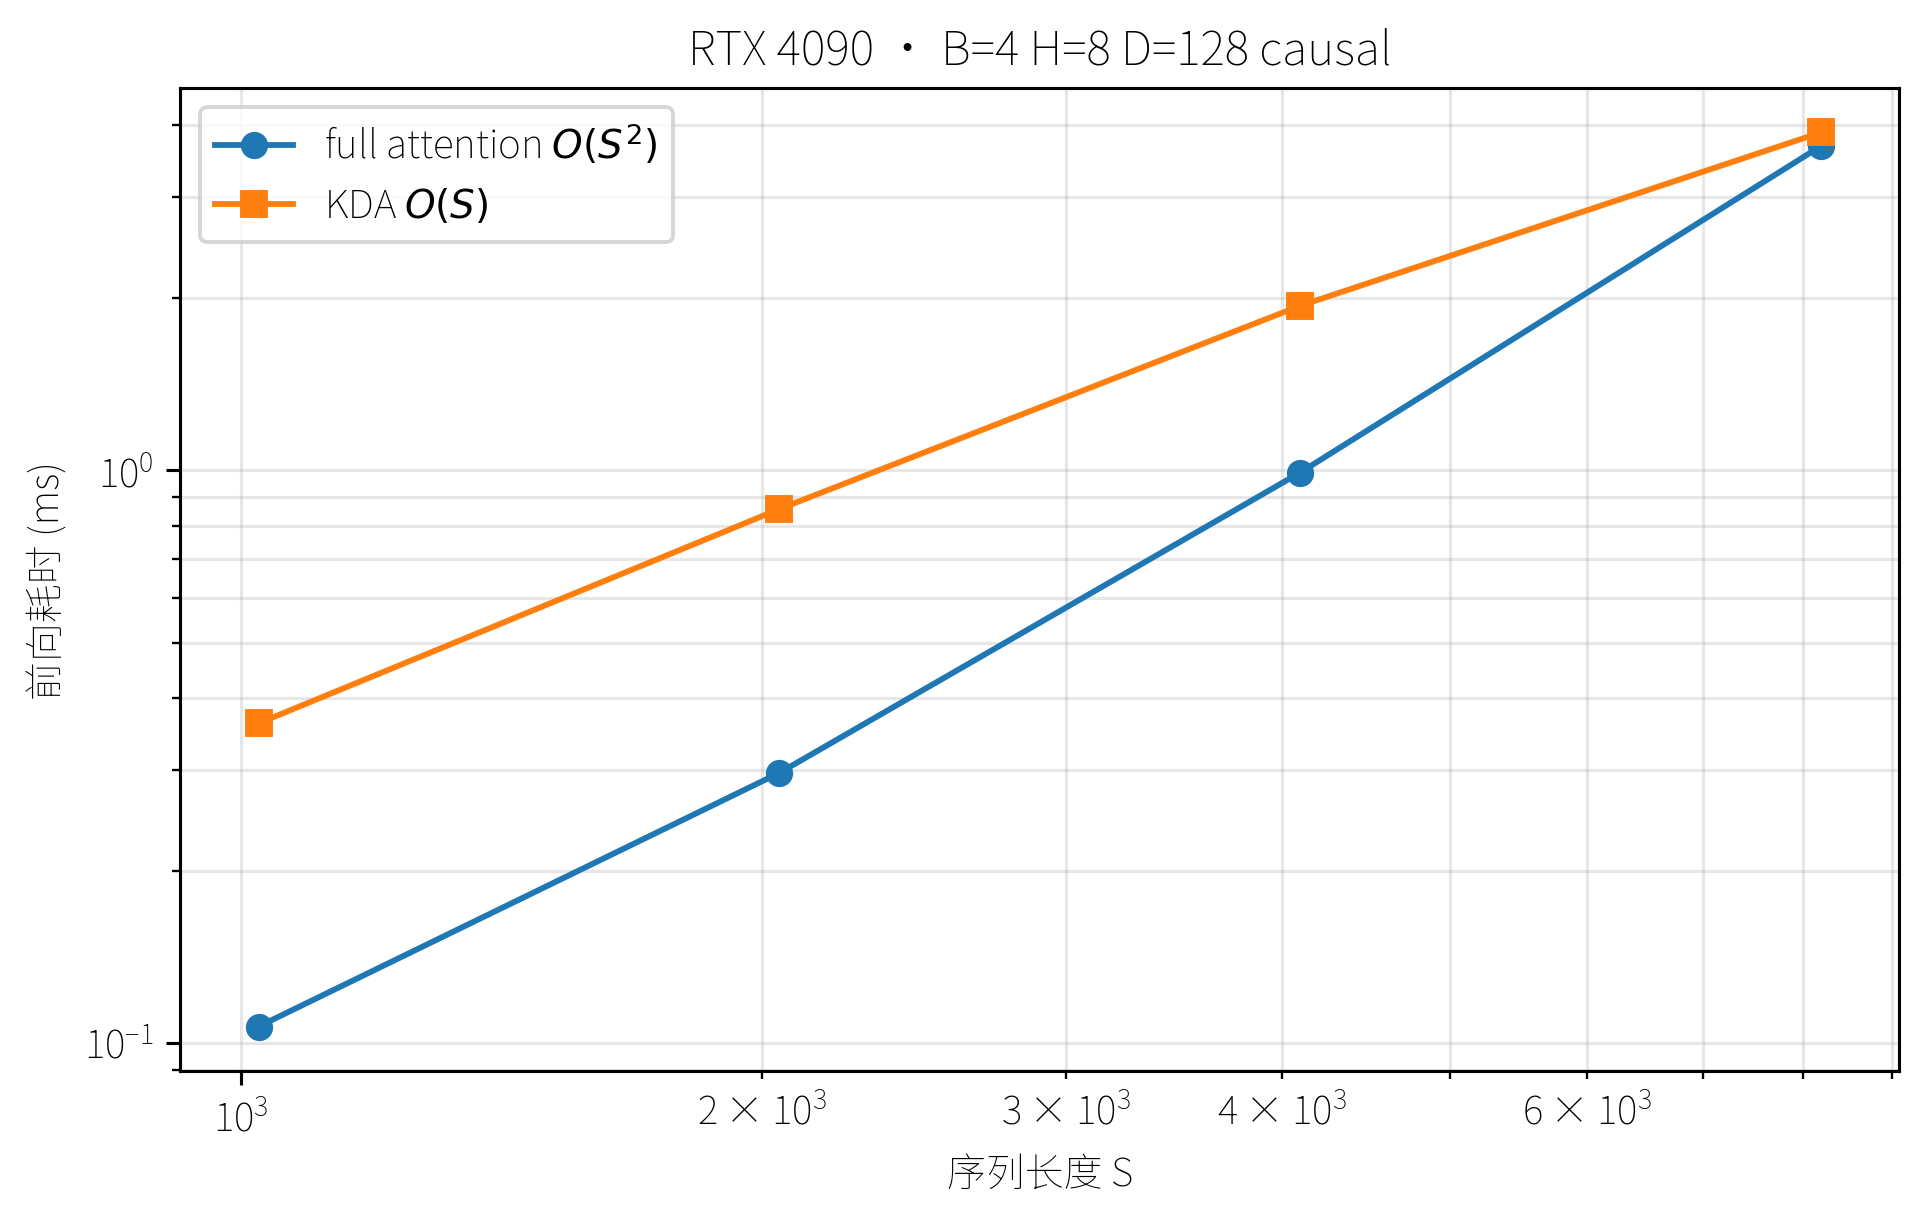

S= 1024  full  0.107ms  KDA  0.362ms (0.30×)
S= 2048  full  0.297ms  KDA  0.856ms (0.35×)
S= 4096  full  0.991ms  KDA  1.937ms (0.51×)
S= 8192  full  3.680ms  KDA  3.887ms (0.95×)


In [9]:
from common import bench_ms
from kda_triton import kda_chunk

B, H, D = 4, 8, 128
Ss = [1024, 2048, 4096, 8192]
full, kda_t = [], []
for S in Ss:
    q = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    k = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    v = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    qb, kb, vb = (x.to(torch.bfloat16) for x in (q, k, v))
    g = F.logsigmoid(torch.randn(B, H, S, D, device="cuda", dtype=torch.float32))
    beta = torch.rand(B, H, S, device="cuda", dtype=torch.bfloat16)
    full.append(bench_ms(lambda: F.scaled_dot_product_attention(q, k, v, is_causal=True)))
    kda_t.append(bench_ms(lambda: kda_chunk(qb, kb, vb, g, beta)))

plt.figure(figsize=(7, 4.5))
plt.plot(Ss, full, "o-", label="full attention $O(S^2)$")
plt.plot(Ss, kda_t, "s-", label="KDA $O(S)$")
plt.xlabel("序列长度 S"); plt.ylabel("前向耗时 (ms)"); plt.yscale("log"); plt.xscale("log")
plt.title("RTX 4090 · B=4 H=8 D=128 causal"); plt.legend(); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
for i, S in enumerate(Ss):
    print(f"S={S:>5}  full {full[i]:6.3f}ms  KDA {kda_t[i]:6.3f}ms ({full[i]/kda_t[i]:.2f}×)")

## 9. 收尾

KDA 把线性注意力的"状态管理"做到了两全：

1. **门控遗忘**（来自 GLA）：$\operatorname{diag}(e^{g_t})$ 按通道选择性遗忘，控制记忆窗口；
2. **delta 纠错**（来自 DeltaNet）：$(I-\beta_t k_tk_t^\top)$ 沿 $k_t$ 擦除旧值再写新值，根治键冲突；
3. **WY 表示**（§4）：把块内串行擦除写成 $(I+T)U=V$，一次三角求逆解开，是 chunk 并行的地基；
4. **逐段精读 + 完整 kernel**（§5–§6）：可读参考实现的每段都对应公式与 Triton 位置，本仓库完整解耦自 fla、与原版数值一致；
5. **反向传播**（§7）：在 DeltaNet 反向（块间 BPTT 扫描 + WY 求逆梯度 + 块内）之上，多一条 per-channel 门控梯度 $dg$，手推已与 autograd 逐位钉死。

退化链 $\textbf{KDA}\xrightarrow{g\equiv0}\textbf{DeltaNet}$ 已数值验证。**下一章** → 13-gated-deltanet：把 delta rule 的
erase/write 进一步解耦成两个门（GDN/GDN-2，Qwen3-Next/3.5）。